# LS-DYNA keyword decks: `.k`, `.key`, `.dyn`

meshio++ reads and writes the **mesh** of an [LS-DYNA](https://lsdyna.ansys.com/) keyword deck: `*NODE`, the `*ELEMENT_*` cards, `*PART` and `*SET_*`, following `*INCLUDE` across files. `*PART` becomes a named cell region (the title is the name, the `pid` the tag) and the sets become point, cell and side regions, so a crash model converts to VTU/VTKHDF with its parts intact. Materials, sections, contacts and loads are skipped: they are not geometry.

The deck below is a small hand-written multi-file model in `tests/python/meshes/lsdyna/`: long-format grid nodes, I10 solids, free-format shells, an `*INCLUDE_PATH`, an include that is deliberately not shipped, five parts and four sets.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

DECKS = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes', 'lsdyna')
TMP = tempfile.mkdtemp()


def show(img, title=None, figsize=(9, 6)):
    """Embed a rendered RGB screenshot as a static image."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def cell_scalar(mesh, values_by_cell):
    """One array per cell block, from a flat block-major array."""
    out, at = [], 0
    for block in mesh.cells:
        out.append(np.asarray(values_by_cell[at:at + len(block.data)]))
        at += len(block.data)
    return out


def part_ids(mesh):
    """The pid of every cell (0 where no part claims it), block-major."""
    n = sum(len(b.data) for b in mesh.cells)
    pid = np.zeros(n, dtype=np.int32)
    for r in mesh.regions:
        if r.kind == 'cell' and r.dim >= 0:
            pid[r.entries] = r.tag
    return pid


def render(mesh, scalars, title, cmap='tab10'):
    """Render a mesh coloured by a per-cell array, or with matplotlib when GL is unavailable."""
    tagged = mp.Mesh(mesh.points, mesh.cells, cell_data={'value': cell_scalar(mesh, scalars)})
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, tagged)
    grid = pv.read(path)
    try:
        pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
        pl.add_mesh(grid, scalars='value', cmap=cmap, show_edges=True, edge_color='#333333',
                    line_width=1.5, scalar_bar_args={'title': 'value'})
        pl.camera_position = 'iso'
        pl.add_axes()
        img = pl.screenshot(return_img=True)
        pl.close()
        show(img, title)
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(projection='3d')
        p = mesh.points
        ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=6, c='#2ec4b6')
        ax.set_title(title)
        plt.show()

## Read a multi-file deck

`crash_main.k` includes the node file, both element files and one file that does not exist. A missing include is a **warning**, not an error: real decks routinely include material and contact files that are not shipped with the mesh. Everything is collected across the files before ids are resolved, so a set can name elements defined in an included file.

meshio warning [lsdyna.cpp:682] LS-DYNA: include file 'materials_not_shipped.k' not found; skipped


<meshio++ mesh object>
  Number of points: 44
  Number of cells:
    hexahedron: 8
    wedge: 4
    tetra: 2
    quad: 12
    line: 3
  Point sets: NODE set 1
  Cell sets: bottom skin, loose tets, matrix, plate, rods, skin, solid parts
  Side sets: loaded face

region         kind    tag  dim  entries
matrix         cell      1    3        8
skin           cell      2    2       12
plate          cell      3    3        4
loose tets     cell      4    3        2
rods           cell      5    1        3
bottom skin    cell      2   -1        4
solid parts    cell      3   -1       14
NODE set 1     point     1   -1        9
loaded face    side      4   -1        1


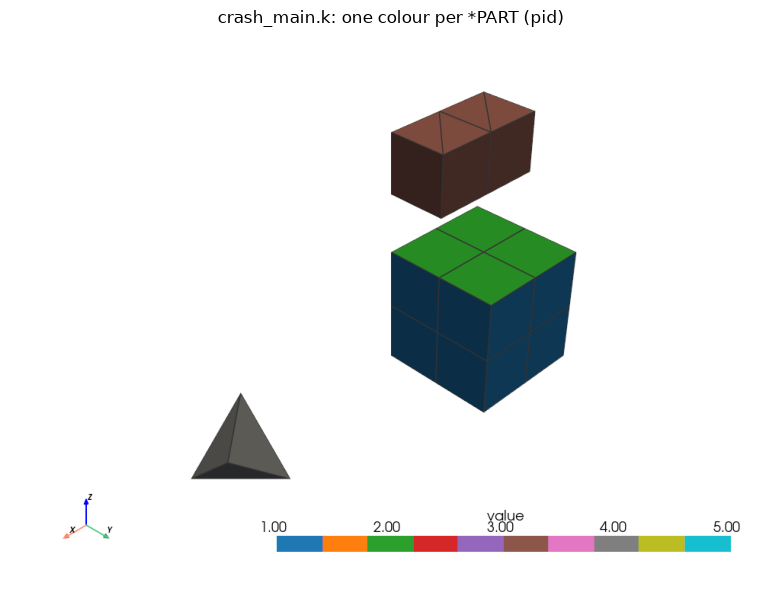

In [2]:
deck = mp.read(os.path.join(DECKS, 'crash_main.k'))
print(deck)
print()
print(f"{'region':14s} {'kind':6s} {'tag':>4s} {'dim':>4s} {'entries':>8s}")
for r in sorted(deck.regions, key=lambda r: (r.kind != 'cell' or r.dim < 0, r.kind, r.tag)):
    print(f'{r.name:14s} {r.kind:6s} {r.tag:4d} {r.dim:4d} {len(r.entries):8d}')

render(deck, part_ids(deck), 'crash_main.k: one colour per *PART (pid)')

Every cell belongs to exactly one part (`dim >= 0`, `tag` = `pid`); the sets have `dim = -1` and the set id as tag. The side region `loaded face` is a `*SET_SEGMENT`: each segment's four nodes are matched to the cell face they name, giving a `(cell, facet)` pair.

In [3]:
loaded = next(r for r in deck.regions if r.name == 'loaded face')
cell, facet = loaded.entries[0]
print('loaded face ->', loaded.entries.tolist(), '(cell', cell, 'of type', deck.cells[0].type + ', facet', facet, ')')
solid_parts = next(r for r in deck.regions if r.name == 'solid parts')
print('*SET_PART 3 (parts 1, 3, 4) ->', len(solid_parts.entries), 'cells: the hexahedra, wedges and tetrahedra')

loaded face -> [[0, 4]] (cell 0 of type hexahedron, facet 4 )
*SET_PART 3 (parts 1, 3, 4) -> 14 cells: the hexahedra, wedges and tetrahedra


## Degenerate elements

LS-DYNA has no tetra, pyramid or wedge card: they are hexahedra with repeated nodes. meshio++ collapses them on read and expands them on write. Both spellings of the wedge that occur in real decks are read, and the node order is chosen so every collapsed cell has a **positive volume**.

wedge n1 n2 n3 n3 n5 n6 n7 n7      -> wedge       [[0, 1, 2, 3, 4, 5]]
tetra n1 n2 n3 n4 n4 n4 n4 n4      -> tetra       [[0, 1, 2, 3]]
pyramid n1 n2 n3 n4 n5 n5 n5 n5    -> pyramid     [[1, 6, 7, 8, 9]]
hexahedron                         -> hexahedron  [[1, 6, 7, 8, 4, 10, 11, 9]]


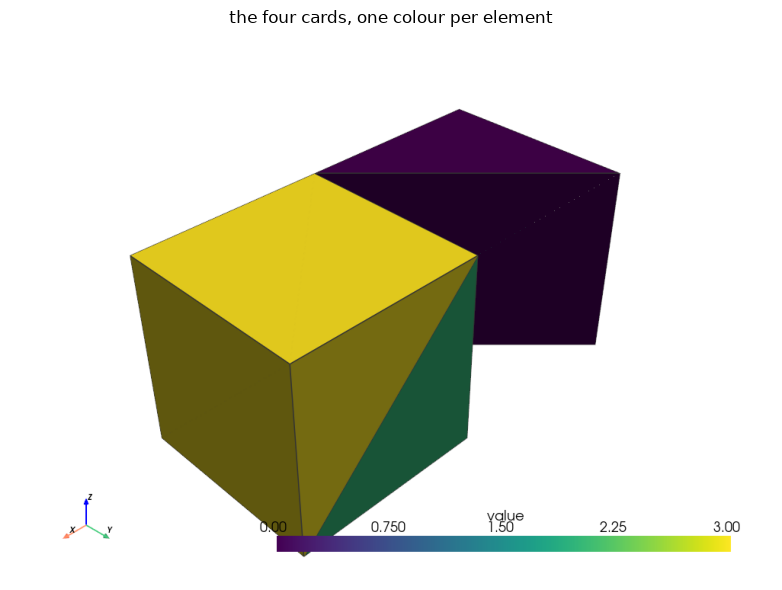

In [4]:
def fmt(values, widths):
    return ''.join(f'{v:>{w}}' for v, w in zip(values, widths))


coords = [(0, 0, 0), (1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 0, 1), (0, 1, 1),
          (2, 0, 0), (2, 1, 0), (1, 1, 0), (1, 1, 1), (2, 0, 1), (2, 1, 1)]
lines = ['*NODE'] + [fmt([i + 1, *map(float, c)], [8, 16, 16, 16]) for i, c in enumerate(coords)]
cards = {
    'wedge n1 n2 n3 n3 n5 n6 n7 n7': [1, 2, 3, 3, 4, 5, 6, 6],
    'tetra n1 n2 n3 n4 n4 n4 n4 n4': [1, 2, 3, 4, 4, 4, 4, 4],
    'pyramid n1 n2 n3 n4 n5 n5 n5 n5': [2, 7, 8, 9, 10, 10, 10, 10],
    'hexahedron': [2, 7, 8, 9, 5, 11, 12, 10],
}
lines += ['*ELEMENT_SOLID']
for eid, (name, nodes) in enumerate(cards.items(), start=1):
    lines.append(fmt([eid, 1, *nodes], [8] * 10))
path = os.path.join(TMP, 'degenerate.k')
with open(path, 'w') as f:
    f.write('\n'.join(lines) + '\n')

small = mp.read(path)
for name, block in zip(cards, small.cells):
    print(f'{name:34s} -> {block.type:11s}', block.data.tolist())
render(small, np.arange(sum(len(b.data) for b in small.cells)), 'the four cards, one colour per element', cmap='viridis')

In [5]:
def volume(points, row):
    """Signed volume of a tetra or wedge in meshio++'s node order (positive = valid)."""
    p = points[row]
    if len(row) == 4:
        return np.linalg.det(p[1:] - p[0]) / 6.0
    n = np.cross(p[1] - p[0], p[2] - p[0])
    return n @ (p[3:].mean(0) - p[:3].mean(0)) / 2.0


for block in small.cells:
    if block.type in ('tetra', 'wedge'):
        print(block.type, 'volume', volume(small.points, block.data[0]))

wedge volume 0.5
tetra volume 0.16666666666666666


## Four card formats, one mesh

A card is one line of fixed columns. **Standard** fields are `I8`/`E16`; **long** (`*KEYWORD LONG=Y`, or `*NODE+` for one keyword) makes *every* field 20 columns; **I10** (`*KEYWORD I10=Y`) widens only the 8-column integers to 10, a different mechanism; **free** format is any line with a comma. They are detected per card and can be mixed in one file. The same model in each layout reads back identically:

In [6]:
def deck_text(layout):
    pts = [(0, 0, 0), (1, 0, 0), (1, 1, 0), (0, 1, 0), (0, 0, 1), (1, 0, 1), (1, 1, 1), (0, 1, 1)]
    head = {'standard': '*KEYWORD', 'long': '*KEYWORD LONG=Y', 'i10': '*KEYWORD I10=Y', 'free': '*KEYWORD'}[layout]
    iw, rw = {'standard': (8, 16), 'long': (20, 20), 'i10': (10, 16)}.get(layout, (0, 0))
    out = [head, '*NODE']
    for i, p in enumerate(pts, start=1):
        if layout == 'free':
            out.append(f'{i},{p[0]:.6e},{p[1]:.6e},{p[2]:.6e}')
        else:
            out.append(fmt([i, *(f'{c:.6e}' for c in p)], [iw, rw, rw, rw]))
    out.append('*ELEMENT_SOLID')
    row = [1, 1, *range(1, 9)]
    out.append(','.join(map(str, row)) if layout == 'free' else fmt(row, [iw] * 10))
    out += ['*PART', 'block', ','.join(['1', '1', '1']) if layout == 'free' else fmt([1, 1, 1], [20 if layout == 'long' else 10] * 3), '*END']
    return '\n'.join(out) + '\n'


reference = None
for layout in ('standard', 'long', 'i10', 'free'):
    p = os.path.join(TMP, f'{layout}.k')
    with open(p, 'w') as f:
        f.write(deck_text(layout))
    m = mp.read(p)
    same = reference is None or (np.array_equal(m.points, reference.points)
                                 and np.array_equal(m.cells[0].data, reference.cells[0].data))
    reference = reference or m
    node_line = deck_text(layout).splitlines()[2]
    print(f'{layout:9s} node card {len(node_line):3d} chars   identical mesh: {same}   {node_line[:44]!r}')

standard  node card  56 chars   identical mesh: True   '       1    0.000000e+00    0.000000e+00    '
long      node card  80 chars   identical mesh: True   '                   1        0.000000e+00    '
i10       node card  58 chars   identical mesh: True   '         1    0.000000e+00    0.000000e+00  '
free      node card  40 chars   identical mesh: True   '1,0.000000e+00,0.000000e+00,0.000000e+00'


## Sets

`*SET_NODE`, `*SET_SOLID`, `*SET_SHELL`, `*SET_BEAM`, `*SET_PART` and `*SET_SEGMENT` (each with `_LIST`, `_GENERATE` and `_TITLE`) become point, cell and side regions. A `*SET_PART` is the union of its parts' elements. Colouring the model by set membership:

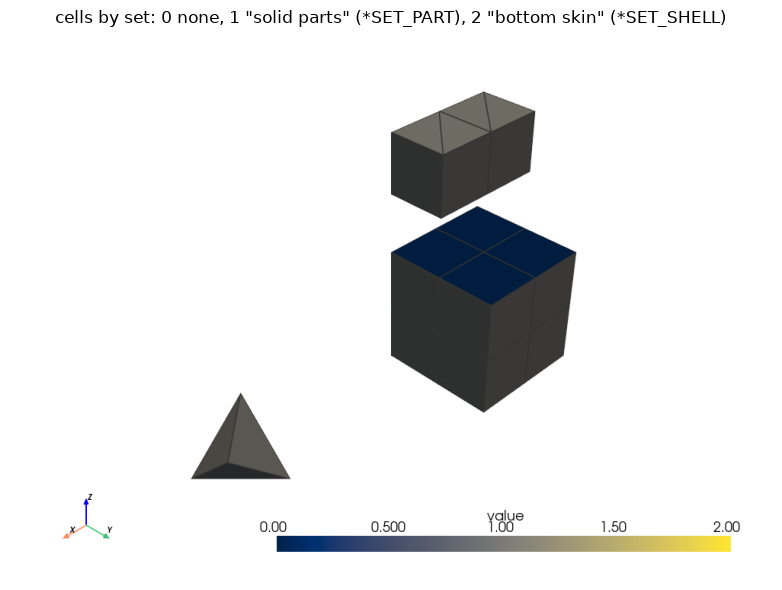

{'NODE set 1': 9, 'bottom skin': 4, 'solid parts': 14, 'loaded face': 1}


In [7]:
membership = np.zeros(sum(len(b.data) for b in deck.cells), dtype=np.int32)
for value, name in ((1, 'solid parts'), (2, 'bottom skin')):
    membership[next(r for r in deck.regions if r.name == name).entries] = value
render(deck, membership, 'cells by set: 0 none, 1 "solid parts" (*SET_PART), 2 "bottom skin" (*SET_SHELL)', cmap='cividis')
print({r.name: len(r.entries) for r in deck.regions if r.dim < 0})

## Writing a deck

The writer emits `*NODE`, one `*ELEMENT_*` keyword per cell block, one `*PART` per part, one `*SET_*_LIST_TITLE` per remaining region and `*END`, with placeholder section and material ids (`1`, `1`) on every part: enough for a mesher to LS-DYNA hand-off. A cell region with a dimension becomes a `*PART` (its tag the `pid`); every other region becomes a set, so nothing is lost. Both engines write byte-identical files.

In [8]:
out = os.path.join(TMP, 'out.k')
mp.write(out, deck)
text = open(out).read().splitlines()
print('\n'.join(text[:6]), '...', sep='\n')
print('\n'.join(l for l in text if l.startswith('*') and not l.startswith(('*NODE', '*ELEMENT'))))

back = mp.read(out)
sig = lambda m: sorted((r.name, r.kind, r.tag, len(r.entries)) for r in m.regions)
print()
print('regions survive the round trip:', sig(back) == sig(deck))
print('cell counts survive           :', {c.type: len(c.data) for c in back.cells} == {c.type: len(c.data) for c in deck.cells})

*KEYWORD
$ Written by meshio++ v15.2.0
*NODE
       1             0.0             0.0             0.0
       2         1.0e+00             0.0             0.0
       3         2.0e+00             0.0             0.0
...
*KEYWORD
*PART
*PART
*PART
*PART
*PART
*SET_NODE_LIST_TITLE
*SET_SHELL_LIST_TITLE
*SET_SOLID_LIST_TITLE
*SET_SEGMENT_TITLE
*END

regions survive the round trip: True
cell counts survive           : True


## Onward: to ParaView

Because the parts are regions, the deck converts to any other meshio++ format with its grouping intact, and `part_ids` above is one line away from a `cell_data` array a post-processor can colour by:

```sh
meshioplusplus convert crash_main.k crash.vtu
meshioplusplus info crash_main.k
```

The limits are spelled out in the [LS-DYNA format page](../../doc/formats/lsdyna.md): 20-node hexahedra, `*PARAMETER` substitution, `*INCLUDE_TRANSFORM` offsets and PGP-encrypted blocks are not handled, and a written deck has placeholder sections and materials.